In [1]:
import pandas as pd
import plotnine as p9

In [2]:
import numpy as np
import scanpy as sc

In [3]:
import anndata

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mplpatches

In [5]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=200)

/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/numba/core/cpu.py:97: UserWarning: Numba extension module 'sparse._numba_extension' failed to load due to 'ModuleNotFoundError(No module named 'numba.targets')'.
/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
2024-04-10 16:26:18.333251: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-10 16:26:25.238982: W tensorflow/tsl/platform/default/dso_loader.cc:66] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared ob

scanpy==1.9.1 anndata==0.7.8 umap==0.5.3 numpy==1.23.5 scipy==1.9.3 pandas==1.5.2 scikit-learn==1.1.3 statsmodels==0.13.5 python-igraph==0.10.2 pynndescent==0.5.8


In [12]:
adata_4lines = anndata.read_h5ad(scifiRNA_directoryname+'/GSM5151353_PD193_fourlines_383k.h5ad')                                

In [7]:
cell_ident_4lines=pd.read_csv(scifiRNA_directoryname+'/GSM5151353_PD193_fourlines_383k.csv.gz',header=0)

In [8]:
cell_ident_4lines

,sample_name,combinatorial_barcode,plate_well,cell_line
0,PD193_fourlines_383k_HEK293T_H01,GCTTATCTAGAGG,H01,HEK293T
1,PD193_fourlines_383k_HEK293T_H03,GTAATGTGGTCAG,H03,HEK293T
2,PD193_fourlines_383k_HEK293T_H05,GGCGCGCGAGCTG,H05,HEK293T
3,PD193_fourlines_383k_HEK293T_H07,GTCCATGTGTGTG,H07,HEK293T
4,PD193_fourlines_383k_HEK293T_H09,GGGAGGAATCCAG,H09,HEK293T
...,...,...,...,...
307,PD193_fourlines_383k_NALM6DSMZ_P16,GCGCGTTACTCAG,P16,NALM6DSMZ
308,PD193_fourlines_383k_NALM6DSMZ_P18,GTGATTGATGGAG,P18,NALM6DSMZ
309,PD193_fourlines_383k_NALM6DSMZ_P20,GGTTACGGGCCGG,P20,NALM6DSMZ
310,PD193_fourlines_383k_NALM6DSMZ_P22,GACCAGCATACAG,P22,NALM6DSMZ


In [11]:
cell_ident_4lines[cell_ident_4lines.cell_line=='K562']

,sample_name,combinatorial_barcode,plate_well,cell_line
168,PD193_fourlines_383k_K562_A02,AACCTCCAACCCA,A02,K562
169,PD193_fourlines_383k_K562_A04,ACGTTTCAGCCAA,A04,K562
170,PD193_fourlines_383k_K562_A06,ATAAGGTTAGATA,A06,K562
171,PD193_fourlines_383k_K562_A08,AATATACCAGACA,A08,K562
172,PD193_fourlines_383k_K562_A10,AGGAGAGACTGTA,A10,K562
...,...,...,...,...
235,PD193_fourlines_383k_K562_P15,GGAGTGTACTTGG,P15,K562
236,PD193_fourlines_383k_K562_P17,GATCGCGAGTACG,P17,K562
237,PD193_fourlines_383k_K562_P19,GCGGTCCCAAGTG,P19,K562
238,PD193_fourlines_383k_K562_P21,GTTCTGGGAGAGG,P21,K562


In [10]:
cell_ident_4lines[cell_ident_4lines.plate_well=='L12'] #confirmed this in the bam file. Well barcode=combinatorial_barcode=BC:Z:(first 13 bases)

,sample_name,combinatorial_barcode,plate_well,cell_line
257,PD193_fourlines_383k_NALM6DSMZ_L12,TCAGGGATCACTC,L12,NALM6DSMZ


In [13]:
adata_4lines.obs=adata_4lines.obs.reset_index().merge(cell_ident_4lines,how="left",left_on=['plate_well'],right_on=["plate_well"]).set_index('index')

In [14]:
sc.pp.calculate_qc_metrics(adata_4lines, percent_top=None, log1p=False, inplace=True) # This is faster and does not break the kernel

In [15]:
df_4lines_sorted=adata_4lines.obs.sort_values(by=['total_counts'],ascending=False)

In [16]:
df_4lines_sorted['rank']=range(1,len(df_4lines_sorted)+1,1)

In [17]:
df_4lines_sorted

,plate_well,sample_name,combinatorial_barcode,cell_line,n_genes_by_counts,total_counts,rank
index,,,,,,,
L11-GCAAAGGGTTTCTTAC,L11,PD193_fourlines_383k_HEK293T_L11,TTCAATTGTGCAC,HEK293T,2029,35188.0,1
M11-ACGTTAGGTAACACTC,M11,PD193_fourlines_383k_HEK293T_M11,CGACCACCTGTAC,HEK293T,2112,29375.0,2
L11-GCGGGTTAGGCAAGCT,L11,PD193_fourlines_383k_HEK293T_L11,TTCAATTGTGCAC,HEK293T,1810,28680.0,3
K19-GGCGTTGGTATCACAC,K19,PD193_fourlines_383k_HEK293T_K19,TCTGCCTACTAAC,HEK293T,1896,26992.0,4
J05-ACTAACGTCTTACGGA,J05,PD193_fourlines_383k_HEK293T_J05,ACGCGGCTCATCA,HEK293T,1761,26570.0,5
...,...,...,...,...,...,...,...
H17-GAACGATCAGTATACC,H17,PD193_fourlines_383k_HEK293T_H17,GGATCGGACCTAG,HEK293T,1,1.0,44976856
H17-GAACGATATTTGCCGC,H17,PD193_fourlines_383k_HEK293T_H17,GGATCGGACCTAG,HEK293T,1,1.0,44976857
H17-GAACGATATTGATAAC,H17,PD193_fourlines_383k_HEK293T_H17,GGATCGGACCTAG,HEK293T,1,1.0,44976858


In [19]:
df_4lines_sorted[0:151788].cell_line.value_counts()

HEK293T             88419
K562                36218
JurkatCas9TCRlib    15443
NALM6DSMZ           11708
Name: cell_line, dtype: int64

In [21]:
df_4lines_sorted[df_4lines_sorted.index=='C16-AGGCCCATCTTGTCAT']

,plate_well,sample_name,combinatorial_barcode,cell_line,n_genes_by_counts,total_counts,rank
index,,,,,,,
C16-AGGCCCATCTTGTCAT,C16,PD193_fourlines_383k_K562_C16,TCGTGAGGGGGTA,K562,117,1096.0,54857


In [22]:
#not sure what the total_counts are. Result for this is 200, I think nUMI=200: 
#samtools view PD193_fourlines_383k_K562.bam | grep r2:Z:AGGCCCATCTTGTCAT | grep C16 | sed's/.*RX:Z:\([ACGT]*\).*/\1/' | sort | uniq -c | wc -l
#Unless some UMI show up multiple times for different genes

#number of reads is 7721 for this cell:
#view PD193_fourlines_383k_K562.bam | grep r2:Z:AGGCCCATCTTGTCAT | grep C16 | wc -l

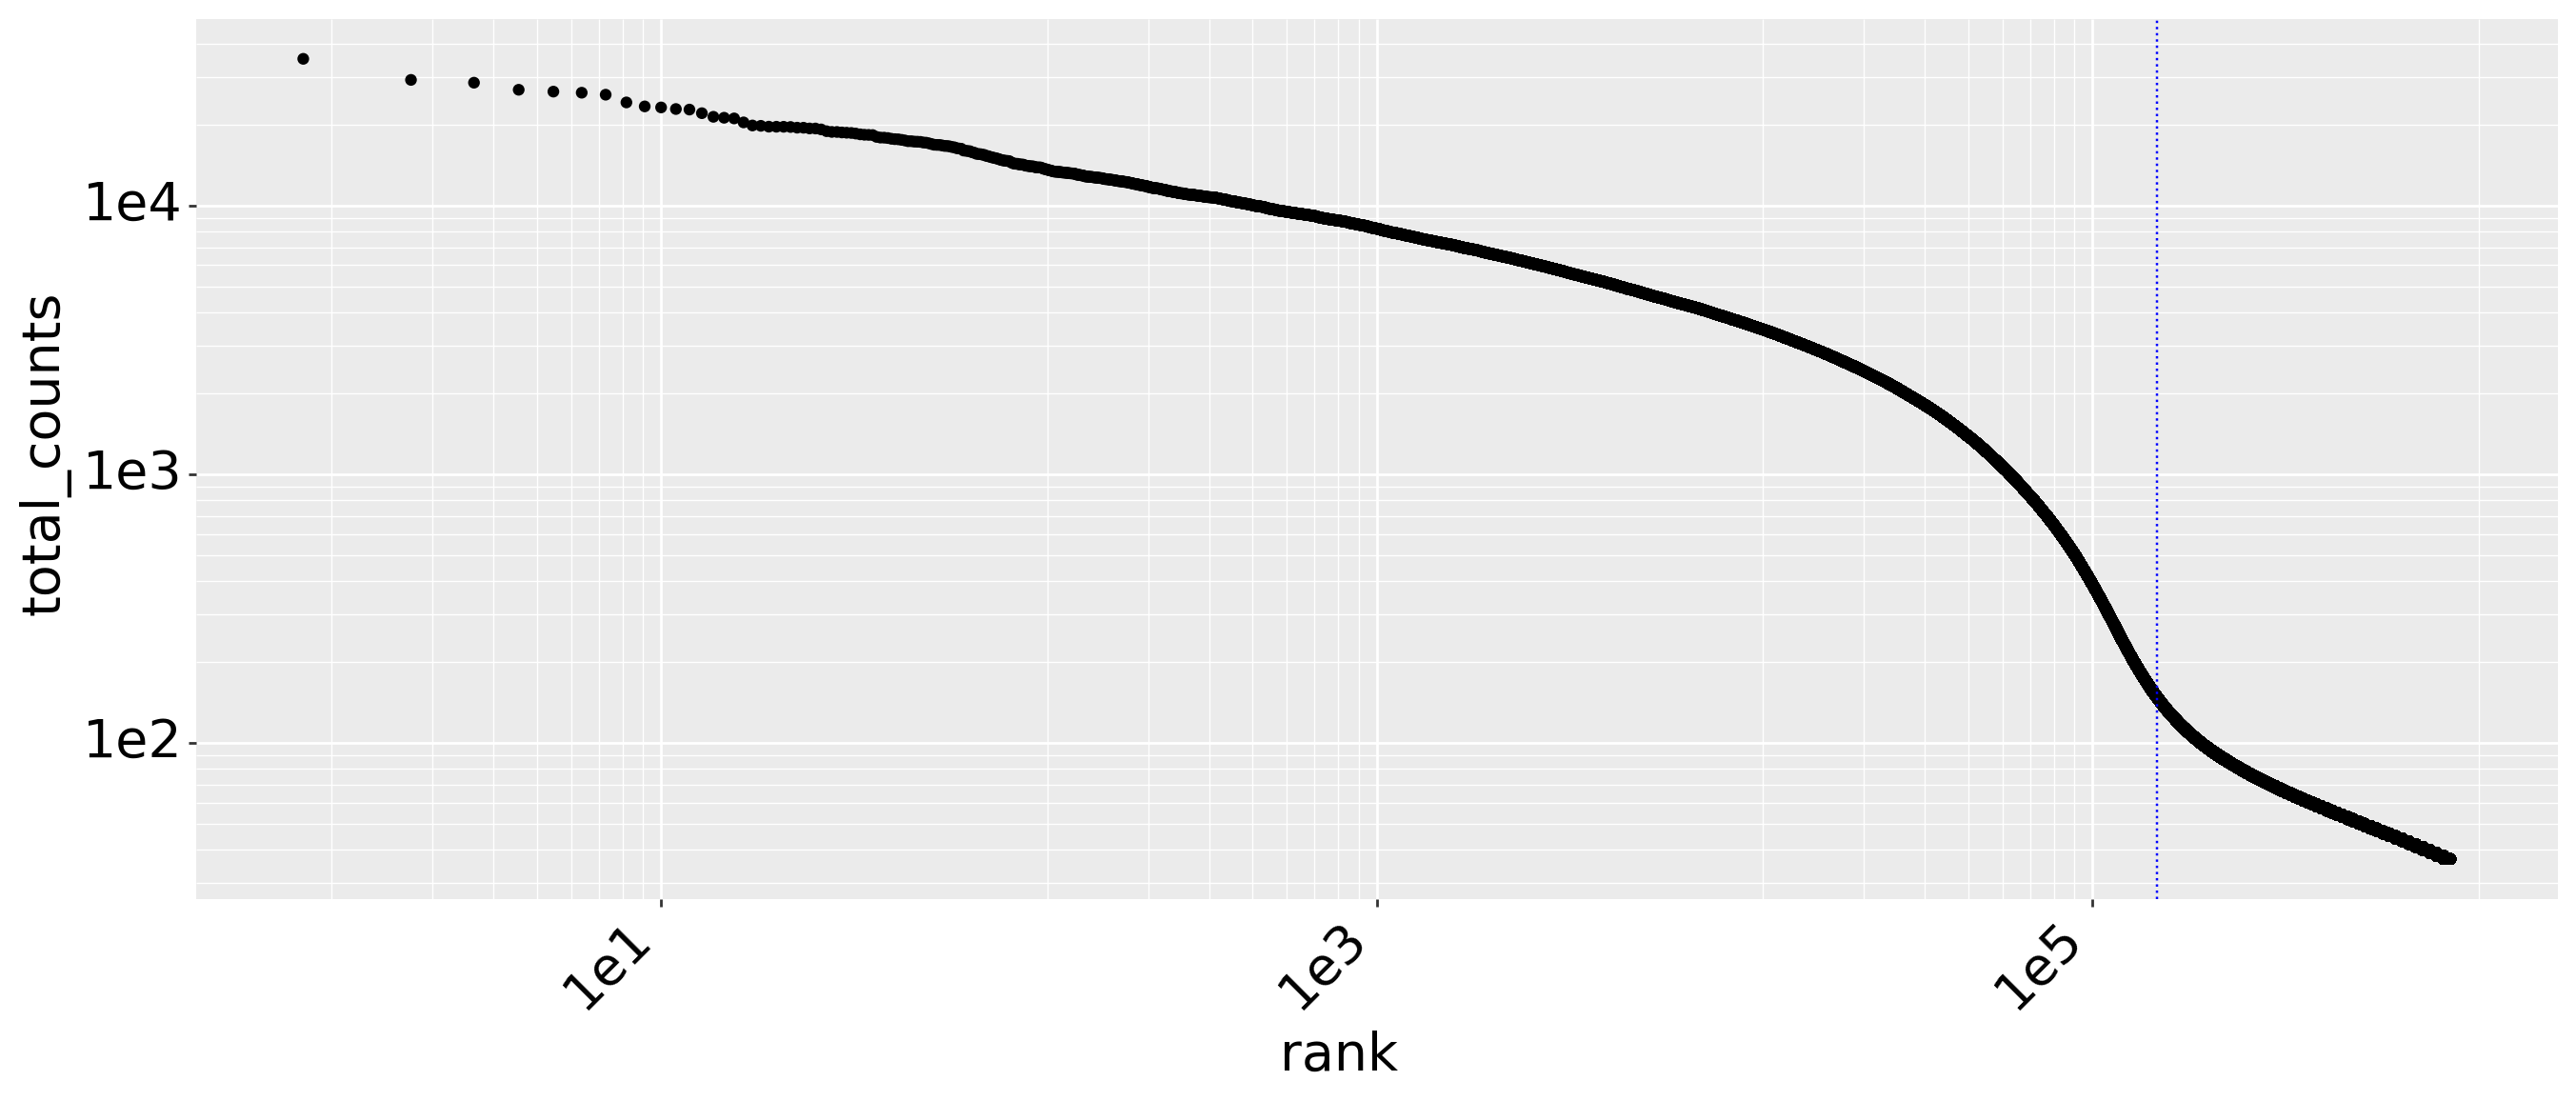

<ggplot: (2932502105221)>

In [14]:
plot=p9.ggplot(data=df_4lines_sorted[0:1000000], #only plotting the first 1 million barcode combinations to save time. Expecting 151788 real cells based on the paper. The whole dataset has 44,976,860 putative cells, most of which are not real cells.
               mapping=p9.aes(x='rank',y='total_counts')
              )
plot+ p9.geom_point() \
+ p9.theme(figure_size=(16, 6)) \
+ p9.theme(axis_text_x=p9.element_text(size=20, colour="black")) \
+ p9.theme(axis_text_x=p9.element_text(angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(size=20, colour="black")) \
+ p9.theme(text=p9.element_text(size=20)) \
+ p9.geom_vline(xintercept=151788,colour=['blue'],linetype='dotted') \
+ p9.scales.scale_y_log10() \
+ p9.scales.scale_x_log10()

#blue line at 151788 is based on the publication that 151788 single-cell transcriptomes were achieved from this experiment

In [15]:
df_4lines_filtered=df_4lines_sorted[df_4lines_sorted['rank'] < 151789] #151789 is based on the publication that 151788 single-cell transcriptomes were achieved from this experiment

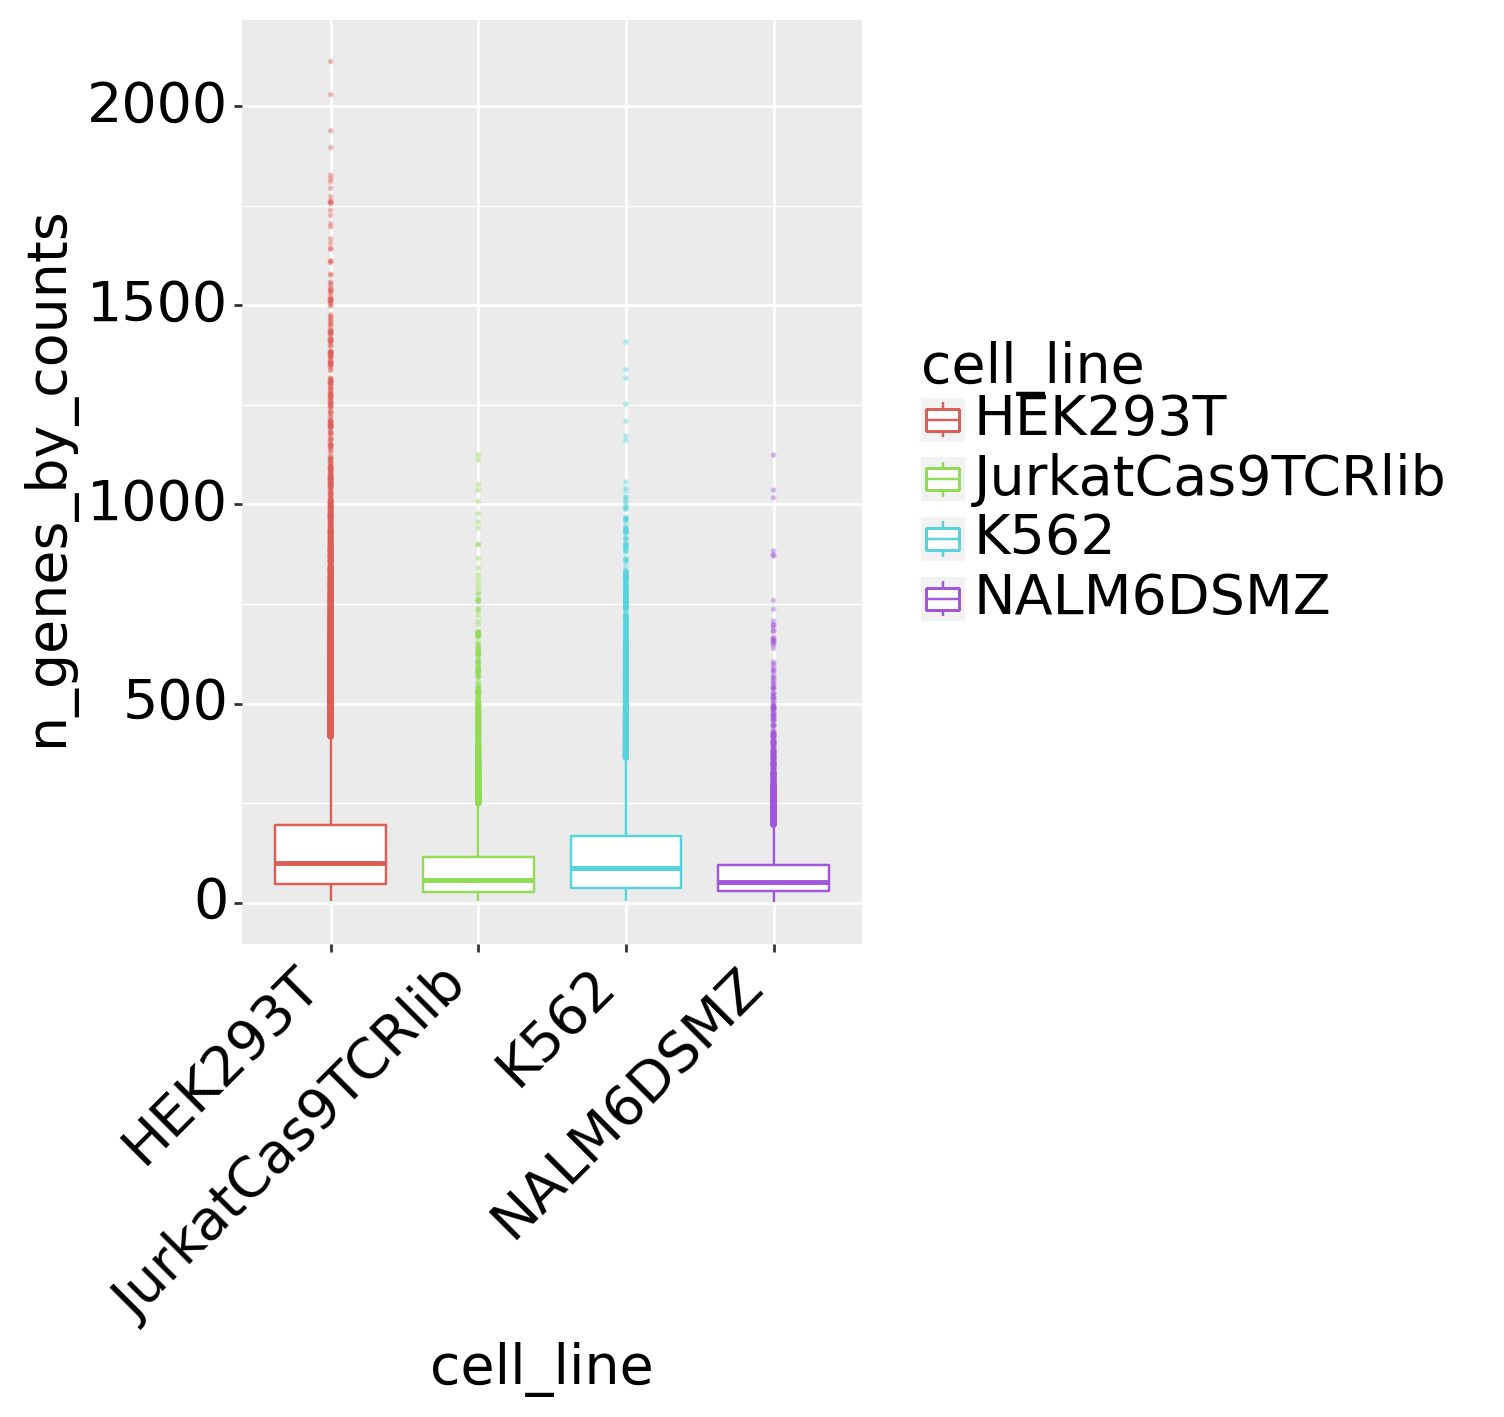

<ggplot: (2932502368479)>

In [16]:
plot=p9.ggplot(data=df_4lines_filtered,
               mapping=p9.aes(x='cell_line',y='n_genes_by_counts',color='cell_line')
              )
plot+ p9.geom_boxplot(outlier_alpha=0.3,outlier_size=0.2) \
+ p9.theme(figure_size=(4, 6)) \
+ p9.theme(axis_text_x=p9.element_text(size=20, colour="black")) \
+ p9.theme(axis_text_x=p9.element_text(angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(size=20, colour="black")) \
+ p9.theme(text=p9.element_text(size=20))

In [33]:
df_4lines_filtered

,plate_well,sample_name,combinatorial_barcode,cell_line,n_genes_by_counts,total_counts,rank
index,,,,,,,
L11-GCAAAGGGTTTCTTAC,L11,PD193_fourlines_383k_HEK293T_L11,TTCAATTGTGCAC,HEK293T,2029,35188.0,1
M11-ACGTTAGGTAACACTC,M11,PD193_fourlines_383k_HEK293T_M11,CGACCACCTGTAC,HEK293T,2112,29375.0,2
L11-GCGGGTTAGGCAAGCT,L11,PD193_fourlines_383k_HEK293T_L11,TTCAATTGTGCAC,HEK293T,1810,28680.0,3
K19-GGCGTTGGTATCACAC,K19,PD193_fourlines_383k_HEK293T_K19,TCTGCCTACTAAC,HEK293T,1896,26992.0,4
J05-ACTAACGTCTTACGGA,J05,PD193_fourlines_383k_HEK293T_J05,ACGCGGCTCATCA,HEK293T,1761,26570.0,5
...,...,...,...,...,...,...,...
P08-ACCTGCTCAACTCCCT,P08,PD193_fourlines_383k_NALM6DSMZ_P08,GCCACTCTTGGGG,NALM6DSMZ,18,147.0,151784
A16-ATCGAGTAGATGTGGA,A16,PD193_fourlines_383k_K562_A16,ATTAAGGAAGTAA,K562,69,147.0,151785
L08-TCAGTTTCATCTGCAA,L08,PD193_fourlines_383k_NALM6DSMZ_L08,TTTCATCCAATAC,NALM6DSMZ,15,147.0,151786


In [17]:
adata_77300Jurkat = anndata.read_h5ad(scifiRNA_directoryname+'/GSM5151370_PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells.h5ad')                                

In [18]:
cell_ident_77300Jurkat=pd.read_csv(scifiRNA_directoryname+'/GSM5151370_PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells.csv.gz',header=0)

In [19]:
adata_77300Jurkat.obs=adata_77300Jurkat.obs.reset_index().merge(cell_ident_77300Jurkat,how="left",left_on=['plate_well'],right_on=["plate_well"]).set_index('index')

In [20]:
sc.pp.calculate_qc_metrics(adata_77300Jurkat, percent_top=None, log1p=False, inplace=True) 

In [21]:
df_77300Jurkat_sorted=adata_77300Jurkat.obs.sort_values(by=['total_counts'],ascending=False)

In [22]:
df_77300Jurkat_sorted['rank']=range(1,len(df_77300Jurkat_sorted)+1,1)

In [23]:
df_77300Jurkat_sorted

,plate_well,sample_name,combinatorial_barcode,material,cell_line,gRNA_ID,gRNA_well,gRNA_seq,TCR_status,n_genes_by_counts,total_counts,rank
index,,,,,,,,,,,,
C08-CGATGATAGGGTATCG,C08,PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells_C08,TTCGTGTGAATTA,MeOH-cells,Jurkat-Cas9,NFKB1_2,PD207_C04,TTACCCGACCACCATGTCCT,stimulated,3868,38078.0,1
K19-ATTTGTCTCACTAGCA,K19,PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells_K19,TCTGCCTACTAAC,MeOH-cells,Jurkat-Cas9,NFATC1_2,PD207_C10,TCCTCCGGCCGACGCCTTCA,stimulated,3978,35373.0,2
J11-CCAGAATTCATCGCCT,J11,PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells_J11,AGCAATTAGGAGA,MeOH-cells,Jurkat-Cas9,FOS_2,PD207_B06,AGGGGGCGGGGACTCCGAAA,stimulated,3466,29452.0,3
I10-CTCTACGAGGGCTCTC,I10,PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells_I10,AAAGTTTATCAAA,MeOH-cells,Jurkat-Cas9,LAT_1,PD207_A05,ACCGGACGCCATCTTCCCGG,stimulated,3578,29341.0,4
C08-CCAGATAGTACAAATG,C08,PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells_C08,TTCGTGTGAATTA,MeOH-cells,Jurkat-Cas9,NFKB1_2,PD207_C04,TTACCCGACCACCATGTCCT,stimulated,3383,28365.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
F22-ACGCCCAATTAGTACC,F22,PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells_F22,CAATCGTAGCCGG,MeOH-cells,Jurkat-Cas9,EGR3_1,PD207_B11,AGGTCACGGTCTTGTTGCCG,unstimulated,1,1.0,20228187
F22-ACGCCCACATGGCCGT,F22,PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells_F22,CAATCGTAGCCGG,MeOH-cells,Jurkat-Cas9,EGR3_1,PD207_B11,AGGTCACGGTCTTGTTGCCG,unstimulated,1,1.0,20228188
F22-ACGCCTAGTCAAAACC,F22,PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells_F22,CAATCGTAGCCGG,MeOH-cells,Jurkat-Cas9,EGR3_1,PD207_B11,AGGTCACGGTCTTGTTGCCG,unstimulated,1,1.0,20228189


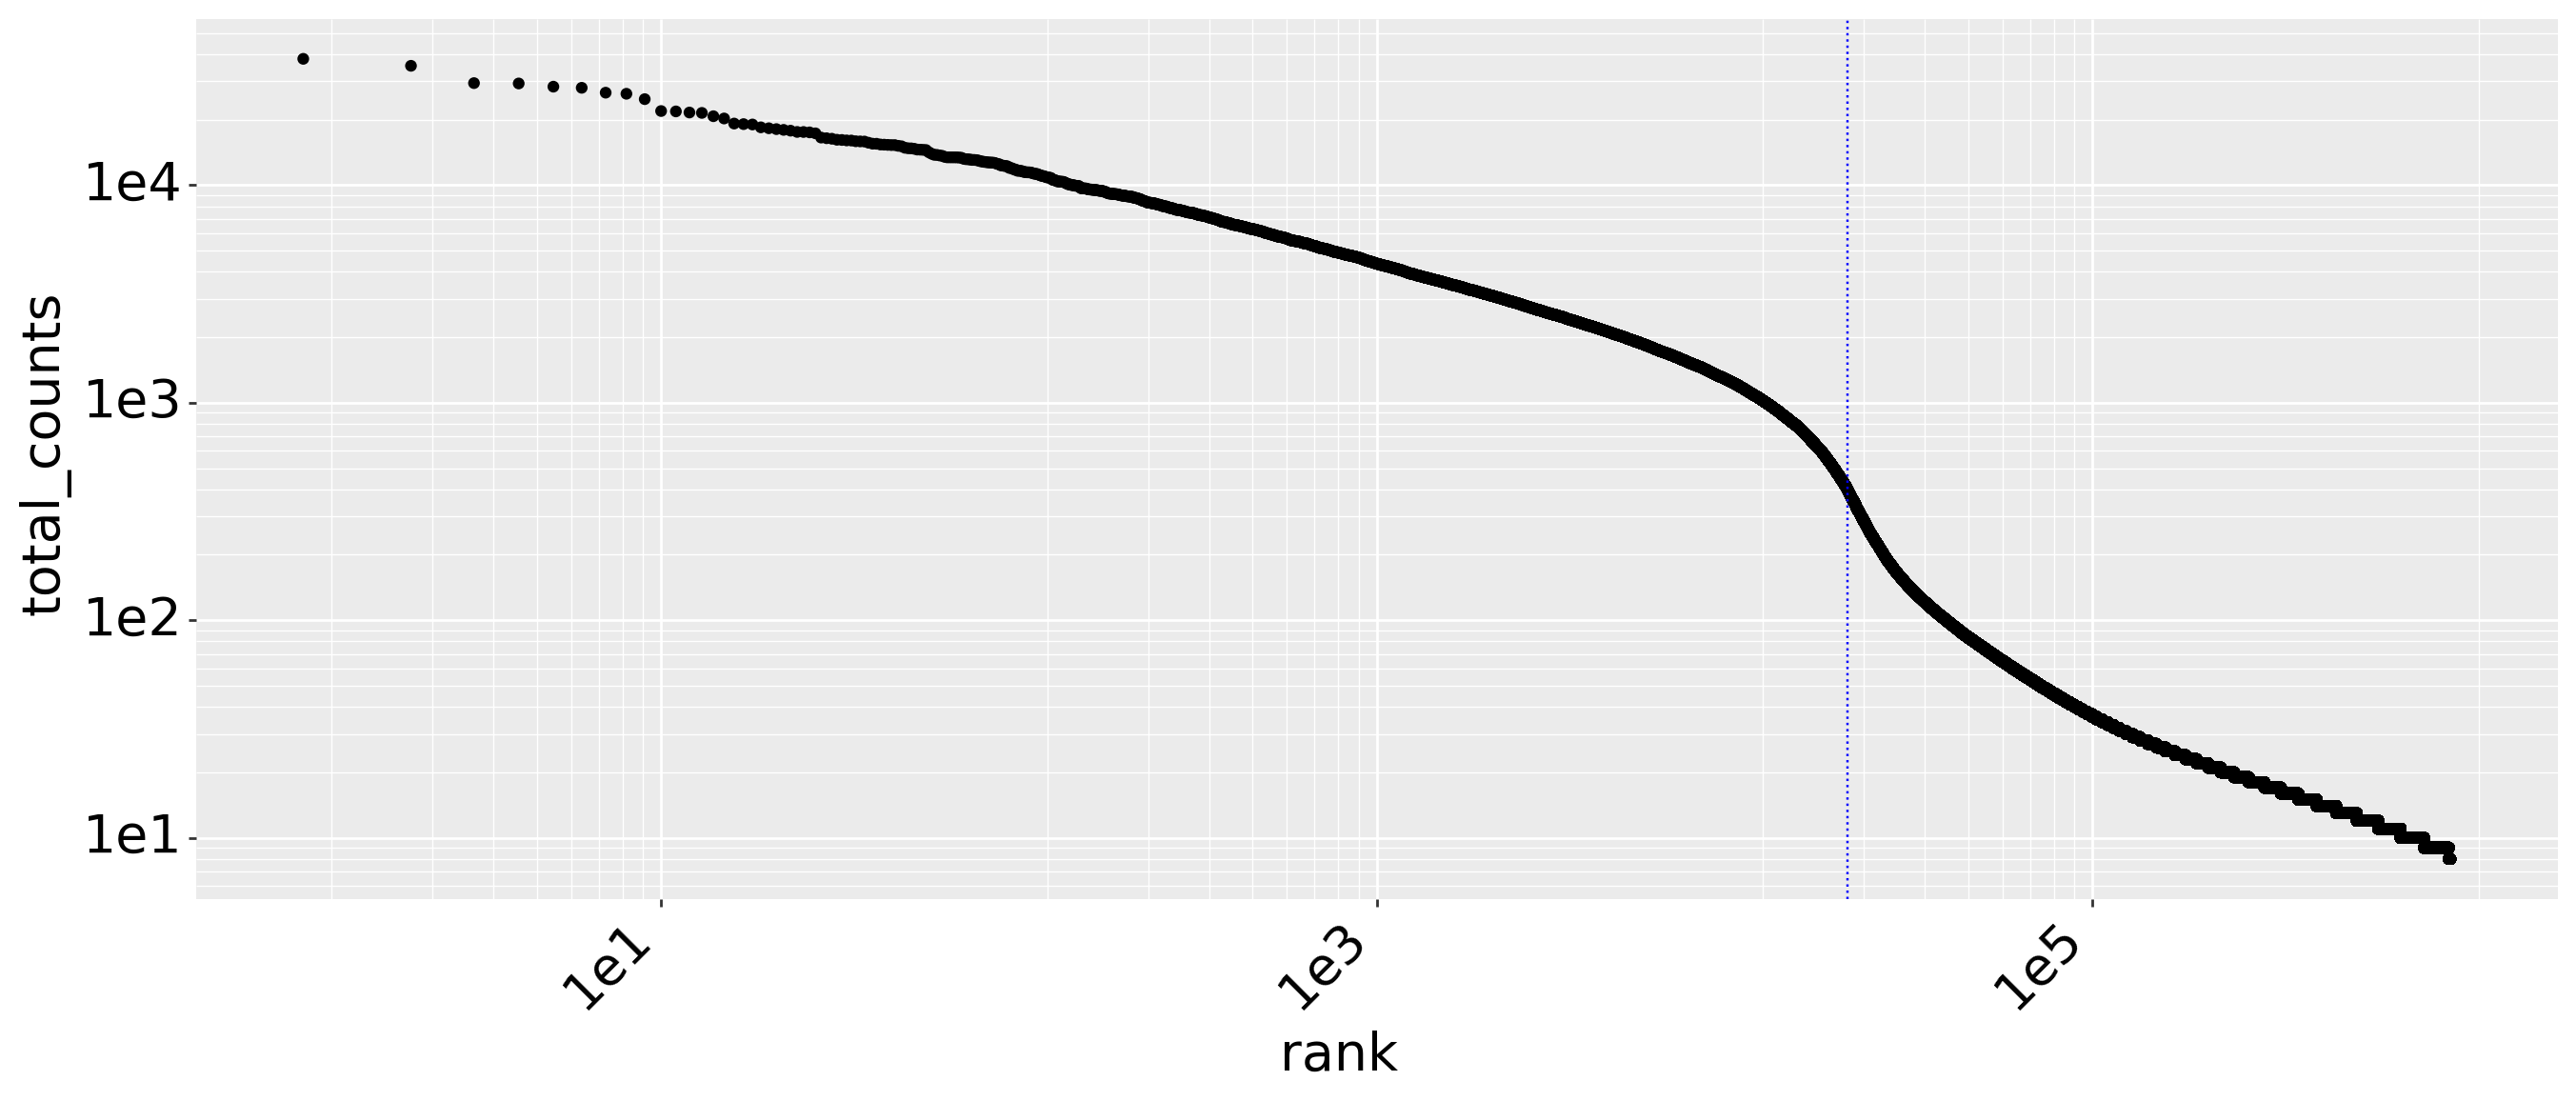

<ggplot: (2932802103465)>

In [25]:
plot=p9.ggplot(data=df_77300Jurkat_sorted[0:1000000], #only plotting the first 1 million barcode combinations to save time. Expecting 20710 real cells based on the paper. The whole dataset has 20,228,191 putative cells, most of which are not real cells.
               mapping=p9.aes(x='rank',y='total_counts')
              )
plot+ p9.geom_point() \
+ p9.theme(figure_size=(16, 6)) \
+ p9.theme(axis_text_x=p9.element_text(size=20, colour="black")) \
+ p9.theme(axis_text_x=p9.element_text(angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(size=20, colour="black")) \
+ p9.theme(text=p9.element_text(size=20)) \
+ p9.geom_vline(xintercept=20710,colour=['blue'],linetype='dotted') \
+ p9.scales.scale_y_log10() \
+ p9.scales.scale_x_log10()

#blue line at 20710 is based on the publication that 20710 single-cell transcriptomes were achieved from this experiment

In [26]:
df_77300Jurkat_filtered=df_77300Jurkat_sorted[df_77300Jurkat_sorted['rank'] < 20711] #20711 is based on the publication that 20710 single-cell transcriptomes were achieved from this experiment

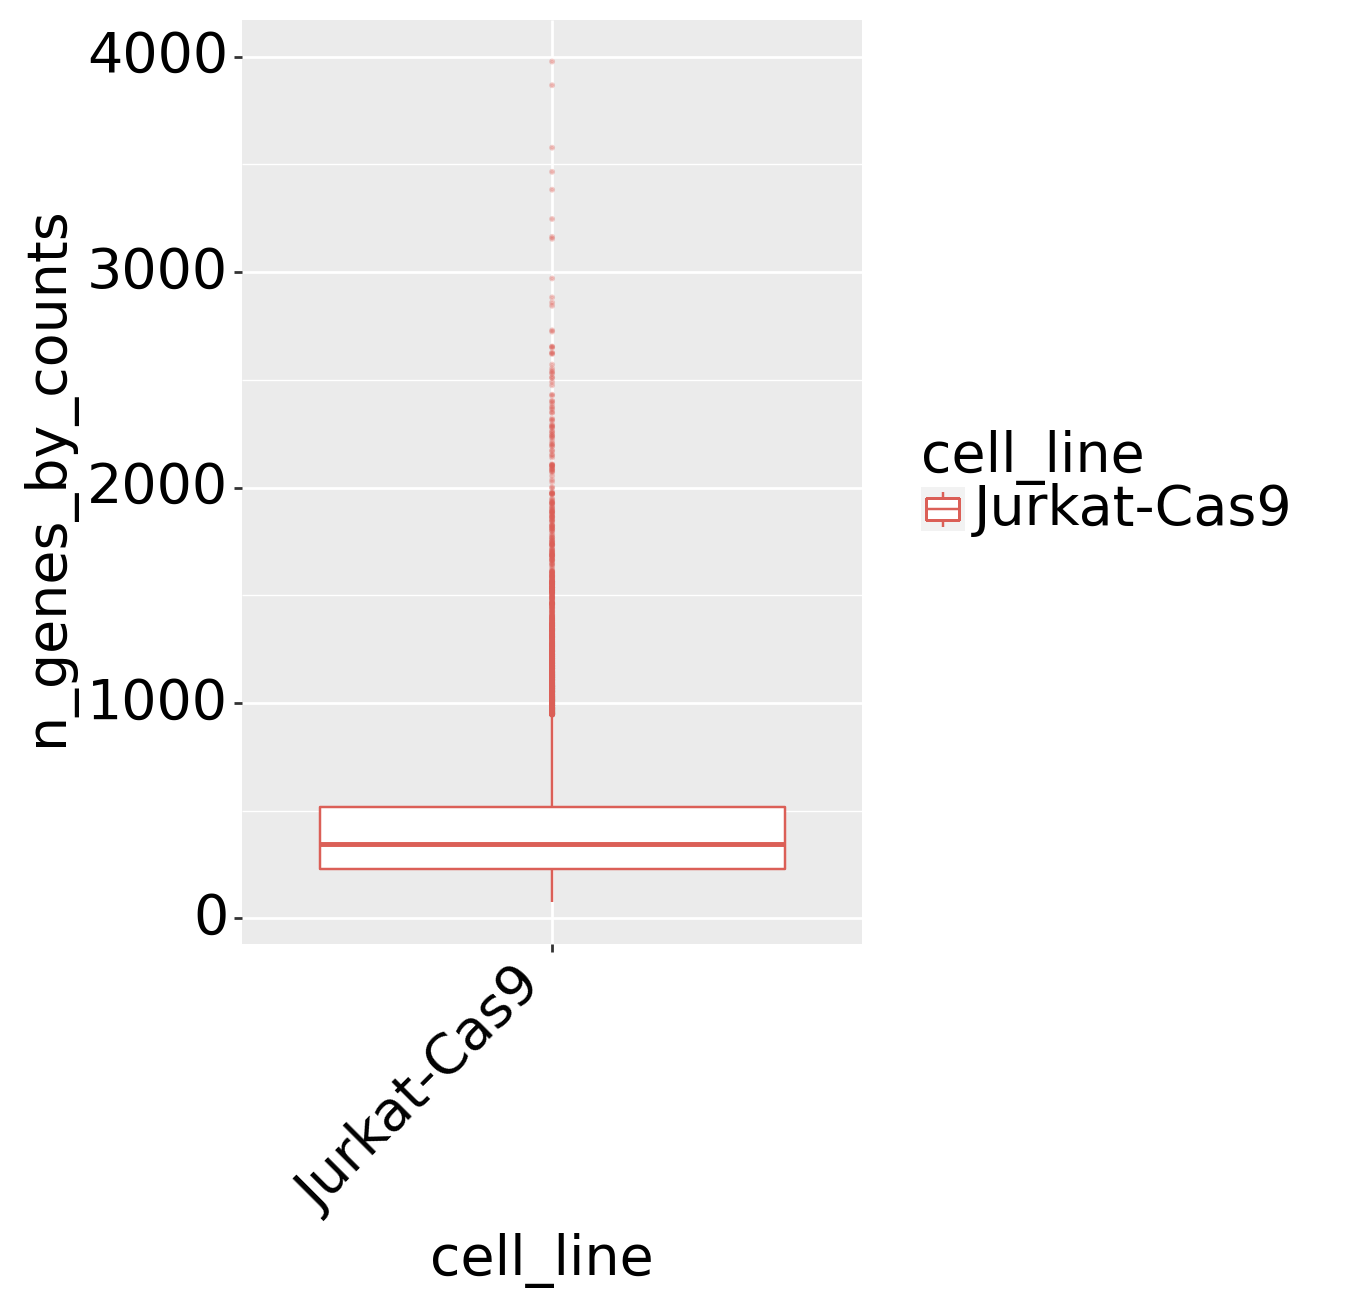

<ggplot: (2932502635005)>

In [27]:
plot=p9.ggplot(data=df_77300Jurkat_filtered,
               mapping=p9.aes(x='cell_line',y='n_genes_by_counts',color='cell_line')
              )
plot+ p9.geom_boxplot(outlier_alpha=0.3,outlier_size=0.2) \
+ p9.theme(figure_size=(4, 6)) \
+ p9.theme(axis_text_x=p9.element_text(size=20, colour="black")) \
+ p9.theme(axis_text_x=p9.element_text(angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(size=20, colour="black")) \
+ p9.theme(text=p9.element_text(size=20))

In [32]:
df_Scifi_combined_filtered=pd.concat([df_4lines_filtered,df_77300Jurkat_filtered],ignore_index=True) #the original index may not be unique since these are from multiple injections

In [33]:
df_Scifi_combined_filtered

,plate_well,sample_name,combinatorial_barcode,cell_line,n_genes_by_counts,total_counts,rank,material,gRNA_ID,gRNA_well,gRNA_seq,TCR_status
0,L11,PD193_fourlines_383k_HEK293T_L11,TTCAATTGTGCAC,HEK293T,2029,35188.0,1,NaN,NaN,NaN,NaN,NaN
1,M11,PD193_fourlines_383k_HEK293T_M11,CGACCACCTGTAC,HEK293T,2112,29375.0,2,NaN,NaN,NaN,NaN,NaN
2,L11,PD193_fourlines_383k_HEK293T_L11,TTCAATTGTGCAC,HEK293T,1810,28680.0,3,NaN,NaN,NaN,NaN,NaN
3,K19,PD193_fourlines_383k_HEK293T_K19,TCTGCCTACTAAC,HEK293T,1896,26992.0,4,NaN,NaN,NaN,NaN,NaN
4,J05,PD193_fourlines_383k_HEK293T_J05,ACGCGGCTCATCA,HEK293T,1761,26570.0,5,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
172493,A08,PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells_A08,AATATACCAGACA,Jurkat-Cas9,120,397.0,20706,MeOH-cells,LCK_2,PD207_A04,CTACGAAGGCTCCAATCCGC,stimulated
172494,K18,PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells_K18,TCATCCAGATCAC,Jurkat-Cas9,259,397.0,20707,MeOH-cells,NFATC1_1,PD207_C09,CCCGTATGAGCTTCGGATTG,stimulated
172495,J15,PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells_J15,ACATACAGCATGA,Jurkat-Cas9,128,397.0,20708,MeOH-cells,EGR1_2,PD207_B08,AAGCGGCCAGTATAGGTGAT,stimulated
172496,J12,PD213_scifi_2_CRISPR-TCR_77300_MeOH-cells_J12,AGACAGTAGTCCA,Jurkat-Cas9,285,397.0,20709,MeOH-cells,FOS_2,PD207_B06,AGGGGGCGGGGACTCCGAAA,stimulated


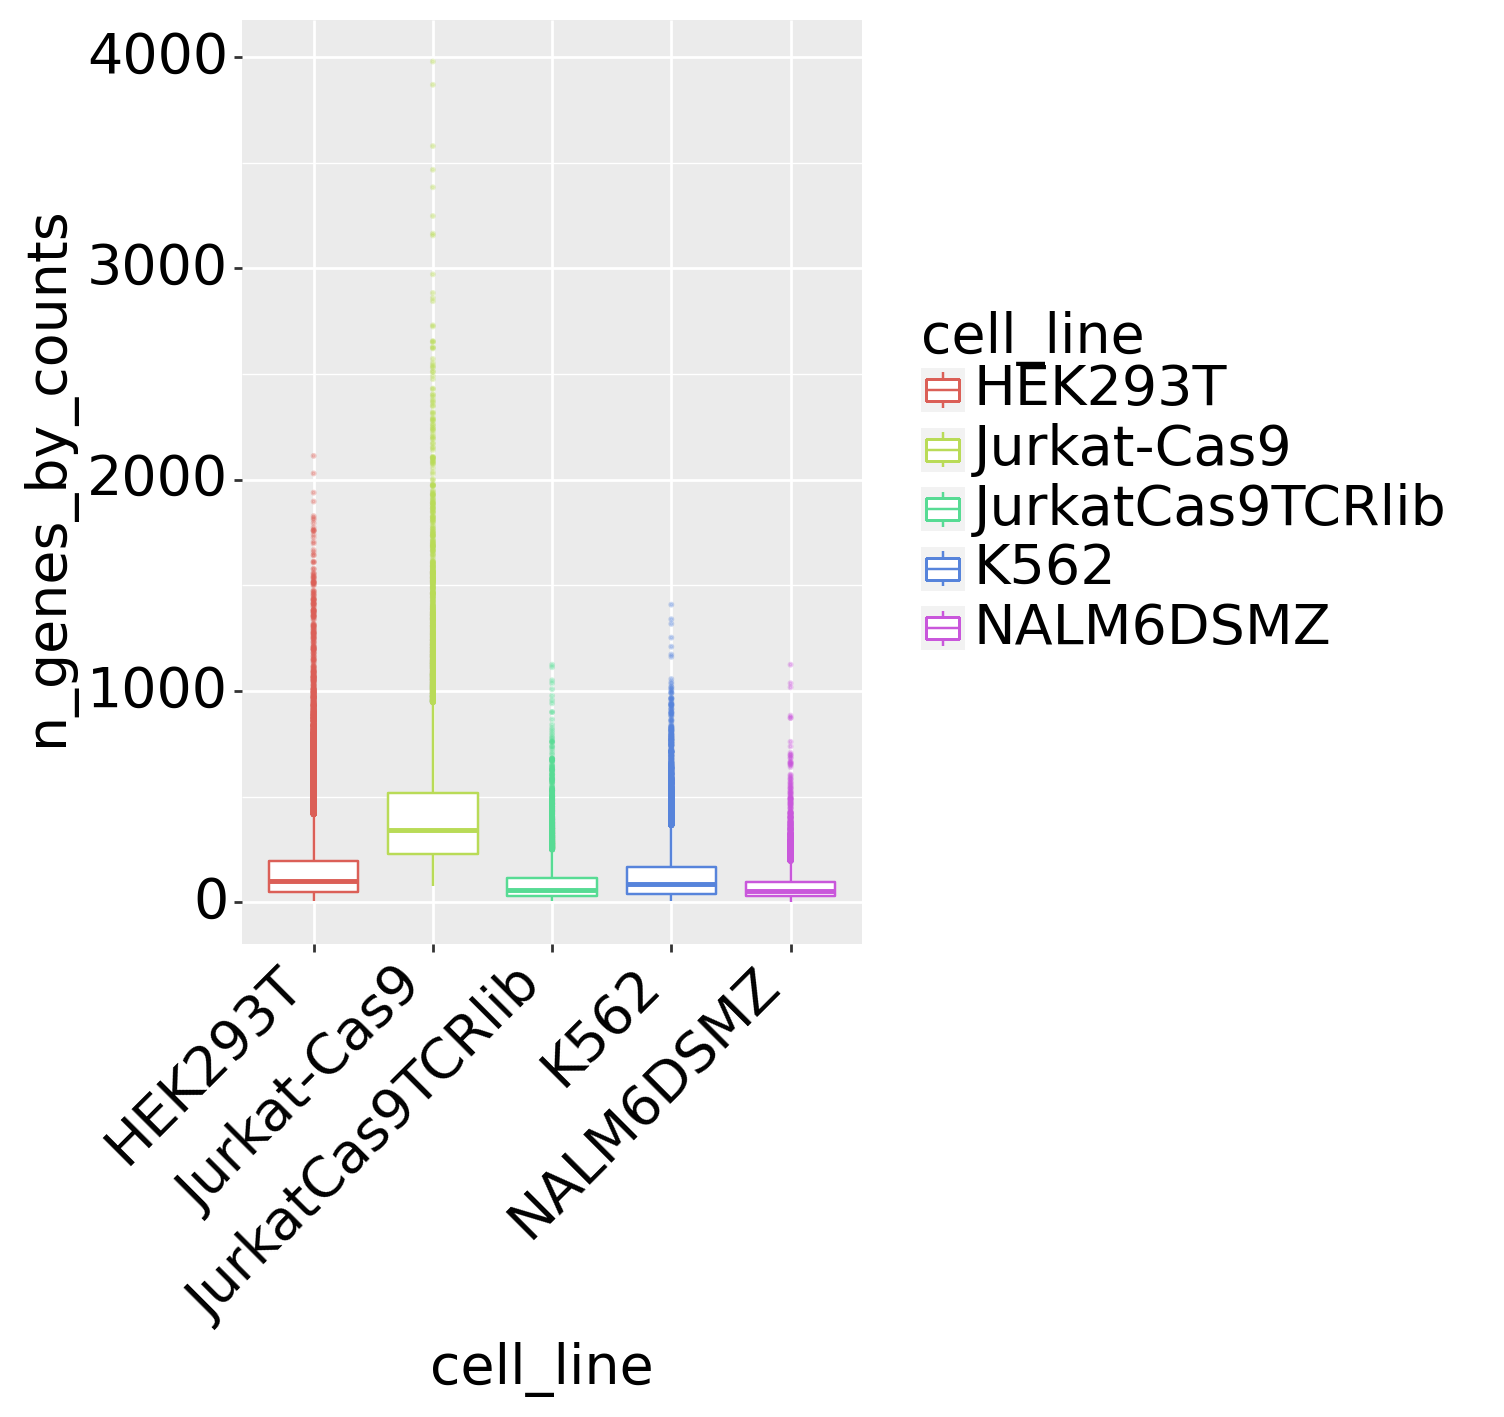

<ggplot: (2932802106170)>

In [35]:
plot=p9.ggplot(data=df_Scifi_combined_filtered,
               mapping=p9.aes(x='cell_line',y='n_genes_by_counts',color='cell_line')
              )
plot+ p9.geom_boxplot(outlier_alpha=0.3,outlier_size=0.2) \
+ p9.theme(figure_size=(4, 6)) \
+ p9.theme(axis_text_x=p9.element_text(size=20, colour="black")) \
+ p9.theme(axis_text_x=p9.element_text(angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(size=20, colour="black")) \
+ p9.theme(text=p9.element_text(size=20))

In [36]:
df_Scifi_combined_filtered.to_csv(output_directoryname+'/ScifiRNA/geneCount_summary.csv',header=True,index=False)